# 01_clean · Data check: STACR 2026-DNA1 reference pool

**Purpose.** Before modeling, make sure the loan-level data is clean and understand what drives this pool's prepayment and credit risk. This notebook is the input side of the pipeline:

```
data/raw (Bloomberg tapes) → src/clean.py → data/processed/*.parquet → 02 (behavior model) → 03 (pool projection) → waterfall
```

**Process.**
1. **Clean** (`src/clean.py`): skip Bloomberg's title row, keep the modeling fields (balance, coupon, FICO, LTV, DTI, age, term, status, occupancy, purpose, state), map account status to a delinquency bucket (C = current, 3/6/9 = 30/60/90+ days), flag loans ever delinquent, set impossible HPI-LTVs of 0 to missing, and add each loan's balance weight.
2. **Summarize** the pool with balance-weighted averages, the standard way to describe a mortgage pool.
3. **Plot** the distributions that drive the model: coupon (refinancing incentive), HPI-adjusted LTV (default and severity), and FICO (default).
4. **List status codes** still to resolve (`B`, `F`).
5. **Anchor** the base-case prepayment speed on the paydown since the Feb 2026 cut-off.

**Data is licensed: clear outputs before committing** (Kernel → Restart & Clear Output).

In [1]:
import sys, warnings
from pathlib import Path

# Find the repo root (the folder that contains src/) so imports work from anywhere
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)  # pandas 2.2 + Python 3.14 noise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:,.4f}".format)
print("repo root:", ROOT)

repo root: /Users/reza/Desktop/mfe-term_3/asset backed scurity market /stacr-crt-pricing


## 1. Clean the raw tapes → `data/processed/*.parquet`

In [2]:
from src import clean
clean.main()

stacr_dna1: 56,433 loans, $19.25bn, 8 loans with unmapped status codes (tape STACR_2026_DNA1_A1_Loan_Level_2026-09.xlsx, as of 2026-09)


In [3]:
pool = pd.read_parquet(clean.PROCESSED / "stacr_dna1.parquet")
pool.head()

**Result · Cleaning.** `clean.py` picked the newest tape, `STACR_2026_DNA1_A1_Loan_Level_2026-09.xlsx` (the post-September pool, converted by Smarajit from Freddie's Clarity loan-level file into the Bloomberg layout), and wrote `data/processed/stacr_dna1.parquet`: **56,433 loans, $19.25bn** ($19,254,307,537.76, matching the Bloomberg CLP). Every row with a Loan ID was kept (no duplicates, no zero balances). The cleaned table adds `dq_bucket` (0 = current), `ever_dq`, and `weight` (each loan's share of pool balance). The only cleaning issue flagged is **8 loans with status codes the map does not cover** (see section 4).

## 2. Pool summary (balance-weighted)

In [4]:
def summarize(df):
    w = df["Current Balance"]
    def wa(c):
        x = pd.to_numeric(df[c], errors="coerce"); m = x.notna()
        return (x[m] * w[m]).sum() / w[m].sum()
    return pd.Series({
        "loans": len(df),
        "current bal ($bn)": w.sum() / 1e9,
        "WA coupon": wa("Gross Coupon"),
        "WA FICO": wa("Credit Score"),
        "WA orig LTV": wa("Original LTV"),
        "WA HPI LTV": wa("HPI Adjusted LTV"),
        "WA DTI": wa("Current Debt to Income"),
        "WA age (mo)": wa("Age"),
        "% bal currently dq": w[df["dq_bucket"] > 0].sum() / w.sum() * 100,
        "loans w/ unmapped status": df["dq_bucket"].isna().sum(),
    })

summarize(pool).to_frame("stacr_dna1")

,stacr_dna1
loans,"56,433.0000"
current bal ($bn),19.2543
WA coupon,6.7613
WA FICO,758.8988
WA orig LTV,75.5650
WA HPI LTV,70.4712
WA DTI,38.5114
WA age (mo),18.3345
% bal currently dq,0.7944
loans w/ unmapped status,8.0000


**Result · Pool summary.**
- **Credit quality is strong**: WA FICO **759** and WA DTI **38.5**.
- **Low LTV**: original LTV **75.6** (all loans 61–80), HPI-adjusted LTV **70.5**, so borrowers have about 30% equity at today's prices.
- **Seasoning**: WA age **18.3 months**: young, but already past the fitted 6-month seasoning ramp (notebook 05), so loans prepay at full speed.
- **Coupons**: WA **6.76%**. That was above the market rate earlier in 2026 (PMMS about 6.05–6.5% from February to June), which explains the fast paydown since cut-off. With PMMS now at **7.28%**, the pool is about 0.5 pp *out of the money*.
- **Delinquency**: **0.79%** of balance is 30+ days late (up from 0.62% on the August tape).

## 3. Distributions that drive your model

Coupon → refi incentive; HPI LTV → default & severity.

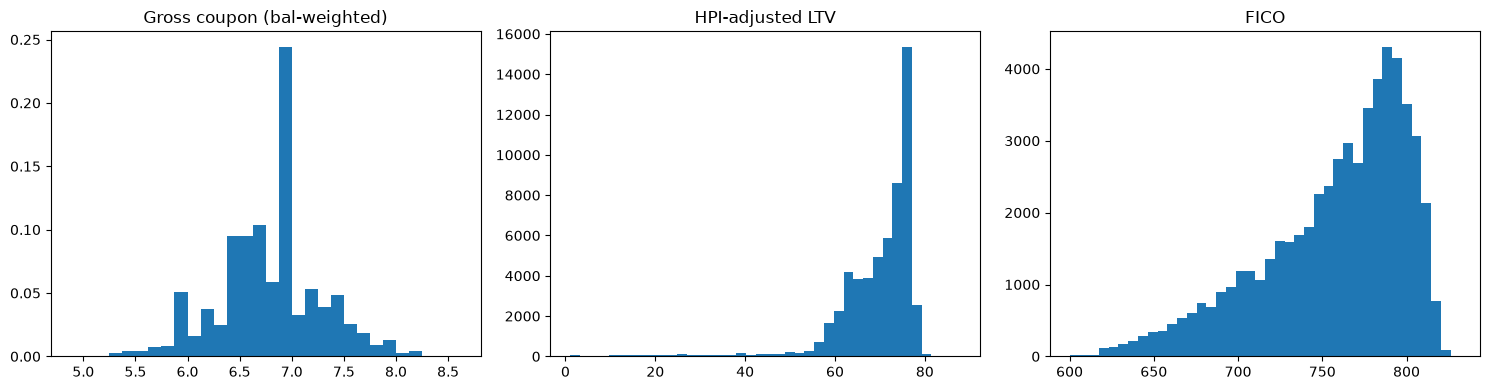

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(pool["Gross Coupon"], bins=30, weights=pool["weight"])
axes[1].hist(pool["HPI Adjusted LTV"].dropna(), bins=40)
axes[2].hist(pool["Credit Score"].dropna(), bins=40)
for ax, t in zip(axes, ["Gross coupon (bal-weighted)", "HPI-adjusted LTV", "FICO"]):
    ax.set_title(t)
plt.tight_layout()

**Result · Distributions (balance-weighted coupon, LTV, FICO).**
- **Coupon**: about **82% of balance** has a coupon between 6.25% and 7.5%. Because coupons are bunched, a rate move shifts most of the pool along the S-curve together, which is why prepayment is so rate-sensitive. From today's 7.28% PMMS, rates would need to fall about 1 pp to put most of the pool on the steep part of the curve.
- **HPI-adjusted LTV**: the middle 80% of loans sit at **60–77** (max 88). No loan is underwater at today's prices. This is the key picture for severity.
- **FICO**: the middle 80% is about **690–800**, with a tail down to about 600. The default model's FICO term matters mainly for that low-FICO tail.

## 4. Status codes still to resolve

> Before mapping `B` and `F` in `STATUS_MAP`: what do you think they mean? What should `^` in Pay History mean?

In [6]:
pool['Account Status'].value_counts()

Account Status
C    55952
3      318
6       78
9       77
B        4
F        4
Name: count, dtype: int64

**Result · Status codes.** STACR has **55,952 current** loans, **318** 30-day, **78** 60-day and **77** 90+-day delinquent, plus **4 `B`** and **4 `F`**. `B`/`F` most likely mean bankruptcy and foreclosure (confirm with the Bloomberg field legend). They are only 8 loans, but they are the most likely to become credit events soon. The model currently treats them as seriously delinquent and puts them straight into the liquidation pipeline.

## 5. Anchor for the base case

The pool was $22.78bn at the Feb 2026 cut-off and is $19.25bn on the September tape.

> Using your `smm_to_cpr`, what CPR does that paydown imply? What else besides prepayment reduced the balance?

**Result · Anchor.** The pool went from **$22.78bn** at the Feb 2026 cut-off to **$19.25bn** after the September payment, a **15.5% paydown** over 7 payments (loan count 64,434 → 56,433, −12.4%). Taking out about 0.1% a month of scheduled principal leaves an SMM of about 2.3%, which is **CPR ≈ 24%**. The base-case prepayment model in notebook 02 should land in the 20–25% range.

## Results and takeaways

- **Size.** STACR DNA1 has **56,433 loans, $19.25bn** after the September 2026 payment (down from $22.78bn and 64,434 loans at the Feb 2026 cut-off). Every loan is a fixed-rate 30-year, about 18 months seasoned (5 loans modified in September restart at age 0 with 40-year terms).
- **Credit quality is strong**: WA FICO 759, WA DTI 38.5.
- **Low LTV**: original LTV 61–80 (WA 75.6); HPI-adjusted LTV **70.5**. Borrowers have about 30% equity, which lowers default rates, but calibration (notebook 05) shows liquidations still lose about 35–45% even at this LTV. No loans have mortgage insurance, since none is above 80 LTV.
- **Coupons** (WA 6.76%) were in the money earlier in 2026, when PMMS was 6.05–6.5%. At today's **7.28%** they are out of the money, so prepayment should slow sharply from the ~23% CPR seen since cut-off. Prepayment is still the dominant risk for timing.
- **Delinquency is low**: 0.79% of balance is currently 30+ days delinquent.
- **To resolve**: 4 loans coded `B` and 4 coded `F` (most likely bankruptcy and foreclosure; confirm with the Bloomberg legend). The model currently treats them as seriously delinquent.
- **Prepayment anchor**: the paydown from $22.78bn to $19.25bn over 7 payments implies roughly **24% CPR**, which is the base-case target for notebook 02.